## Data Exploration

In [1]:
import os,re
from collections import Counter
import email.policy, email.parser

import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from wordcloud import WordCloud, STOPWORDS
import numpy as np
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.metrics import accuracy_score, f1_score, fbeta_score
from sklearn.metrics import ConfusionMatrixDisplay


### Load Datasets

In [2]:
# Load datasets
spam_assassin_datasets = os.path.join("./input", "hamnspam")
ham_folder = os.path.join(spam_assassin_datasets, "ham")
spam_folder = os.path.join(spam_assassin_datasets, "spam")

def load_email(filename):
    with open(filename, "rb") as f:
        return email.parser.BytesParser(policy=email.policy.default).parse(f)

In [3]:
hams_files = [os.path.join(ham_folder, f) for f in sorted(os.listdir(ham_folder))]
spams_files = [os.path.join(spam_folder, f) for f in sorted(os.listdir(spam_folder))]

print(f"Total Number of Ham Data: {len(hams_files)}")
print(f"Total Number of Spam Data: {len(spams_files)}")

hams = [load_email(ham) for ham in hams_files]
spams = [load_email(spam) for spam in spams_files]

def html_to_plain(email):
    try:
        soup = BeautifulSoup(email.get_content(), 'html.parser')
        return soup.text.replace('\n\n','')
    except:
        return "empty"

def email_to_plain(email):
    for part in email.walk():
        content_type = part.get_content_type()
        if content_type == 'text/plain':
            try:
                return part.get_content()
            except:
                return str(part.get_payload())
        if content_type == "text/html":
            return html_to_plain(part)

# str or None
parsed_ham = [email_to_plain(ham) for ham in hams]
parsed_spam = [email_to_plain(spam) for spam in spams]

Total Number of Ham Data: 2551
Total Number of Spam Data: 500


### Preprocessing

In [4]:
def preprocess(text, is_stem = False):
    if not text:
        return 'empty'

    # make lowercase
    text = text.lower().strip()

    # Remove Email
    text = re.sub("\S*@\S*\s?", ' ', text)

    # Remove URL
    text = re.sub('http\S+',' ', text)
    
    # remove puncutation
    puncutations = ('.', ',', '!', '?', '-', '+', '(', ')', '{', '}','[', ']', "'", '"', "_", ":", "|", "$", "<", ">", "=", "*", "&", '/', "#", ";", '�', '~', '“', '\\', '’', '”', '^', '`', '—', '‘', '¿')
    for punc in puncutations:
        text = text.replace(punc, ' ')
    
    # Remove numbers
    text = re.sub('[0-9]', ' ', text)

    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in set(STOPWORDS) and len(word) > 1])

    # Stem if required
    if is_stem:
        stemmer = PorterStemmer()
        text = ' '.join([stemmer.stem(word) for word in text.split()])

    return text

processed_hams = [preprocess(ham) for ham in parsed_ham]
processed_spams = [preprocess(spam) for spam in parsed_spam]

## Wordcloud

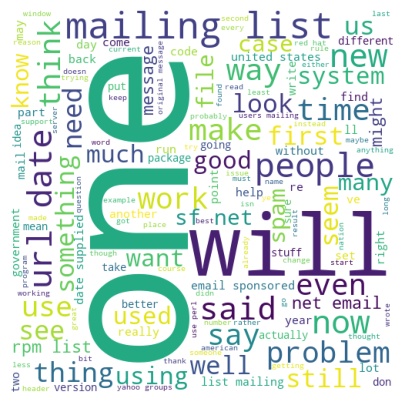

In [5]:
ham_word_cloud = WordCloud(width = 500, height = 500,
                background_color ='white',
                min_font_size = 10).generate(' '.join(processed_hams))

plt.figure(figsize = (5, 5), facecolor = None)
plt.imshow(ham_word_cloud)
plt.axis("off")
plt.show()

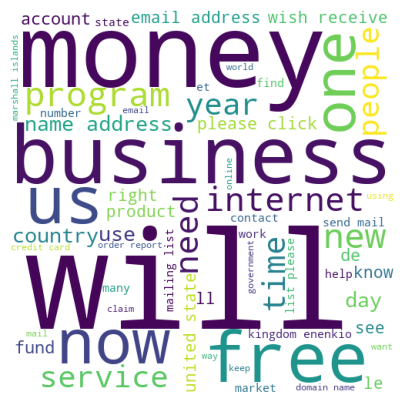

In [6]:
spam_word_cloud = WordCloud(width = 500, height = 500,
                background_color ='white',
                stopwords = set(STOPWORDS),
                min_font_size = 10).generate(' '.join(processed_spams))

plt.figure(figsize = (5, 5), facecolor = None)
plt.imshow(spam_word_cloud)
plt.axis("off")
plt.show()

# Frquency Graph

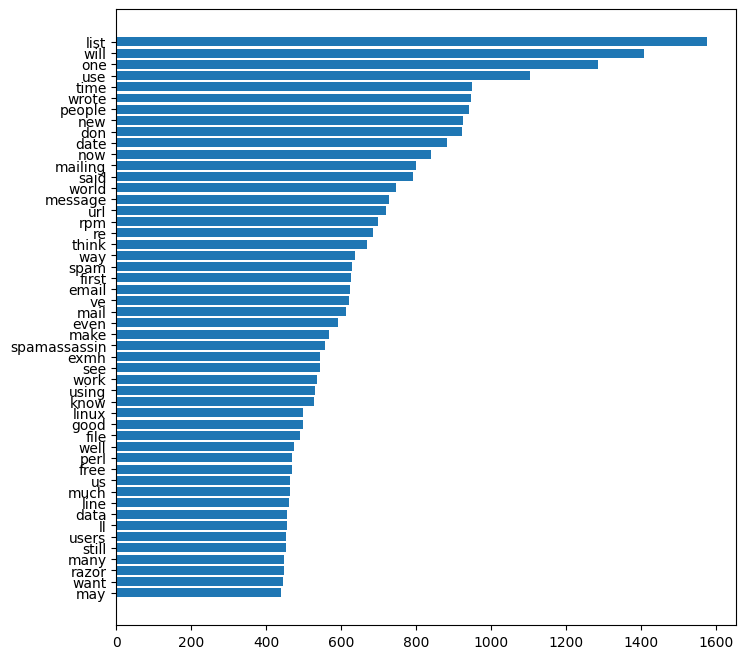

In [7]:
ham_word_counter = Counter(' '.join(processed_hams).split())
most_common_map = ham_word_counter.most_common(50)

words, freq = zip(*reversed(most_common_map))

plt.figure(figsize=(8, 8))
plt.barh(words, freq) 
plt.show()

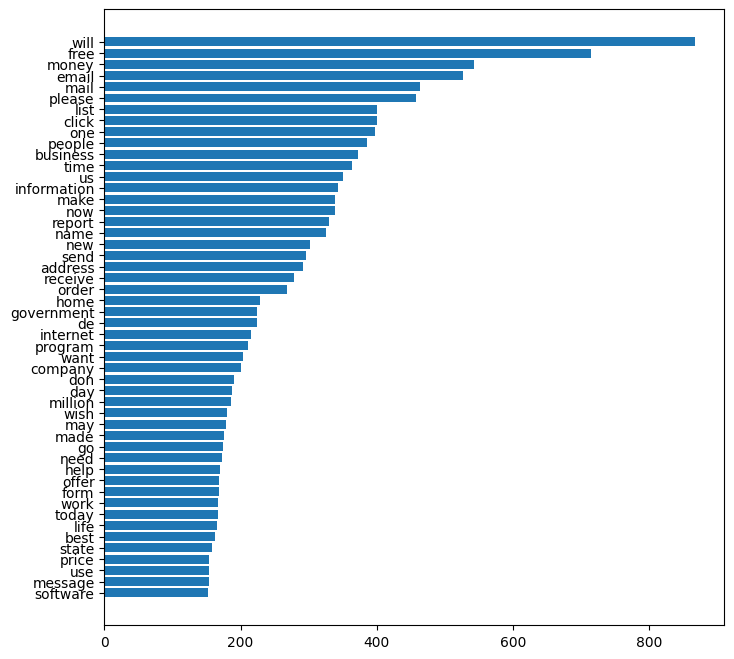

In [8]:
spam_word_counter = Counter(' '.join(processed_spams).split())
most_common_map = spam_word_counter.most_common(50)

words, freq = zip(*reversed(most_common_map))

plt.figure(figsize=(8, 8))
plt.barh(words, freq) 
plt.show()

# Vectorizing

In [9]:
# Stem the string
stemmed_hams = [preprocess(ham, is_stem=True) for ham in parsed_ham]
stemmed_spams = [preprocess(spam, is_stem=True) for spam in parsed_spam]

In [10]:
# Correct imbalance class size
sample_size = min(len(stemmed_hams), len(stemmed_spams))

X = np.array(stemmed_hams + stemmed_spams)
y = np.array([0] * len(stemmed_hams) + [1] * len(stemmed_spams))

# random_sample = np.random.choice(X.shape[0], size=sample_size)
# X, y = X[random_sample], y[random_sample]

print(X.shape, y.shape)

(3051,) (3051,)


### Vectorize Features (Bag of words + count or tfid)

In [11]:
# Count Vectorizer
count_vectorizer = CountVectorizer()
count_vector = count_vectorizer.fit_transform(X)
print(count_vector.shape)

(3051, 30986)


In [12]:
# TFID Vectorizer
tfidvectorizer = TfidfVectorizer()
tfid_vector = tfidvectorizer.fit_transform(X)
print(tfid_vector.shape)

(3051, 30986)


In [13]:
# Use TFID Vectorizer
X = tfid_vector.toarray()
print(X.shape)

(3051, 30986)


# Principal Component Analysis (PCA)

In [14]:
NUM_OF_FEATURES_TO_KEEP = 3
X_PCA = PCA(n_components=NUM_OF_FEATURES_TO_KEEP).fit_transform(X)

(2551, 3) (500, 3)


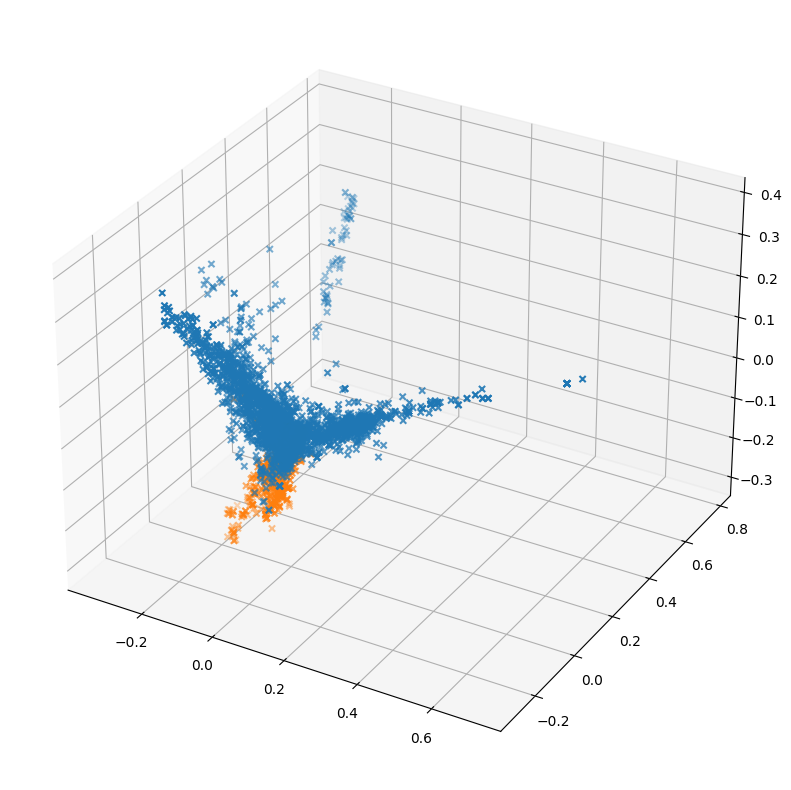

In [15]:
X_ham = X_PCA[y == 0]
X_spam = X_PCA[y == 1]

print(X_ham.shape, X_spam.shape)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

ax.scatter(X_ham[:, 0], X_ham[:, 1], X_ham[:, 2], marker="x")
ax.scatter(X_spam[:, 0], X_spam[:, 1], X_spam[:, 2], marker="x")

plt.show()

# LDA

In [16]:
X_LDA = LatentDirichletAllocation(n_components=NUM_OF_FEATURES_TO_KEEP).fit_transform(X)

(2551, 3) (500, 3)


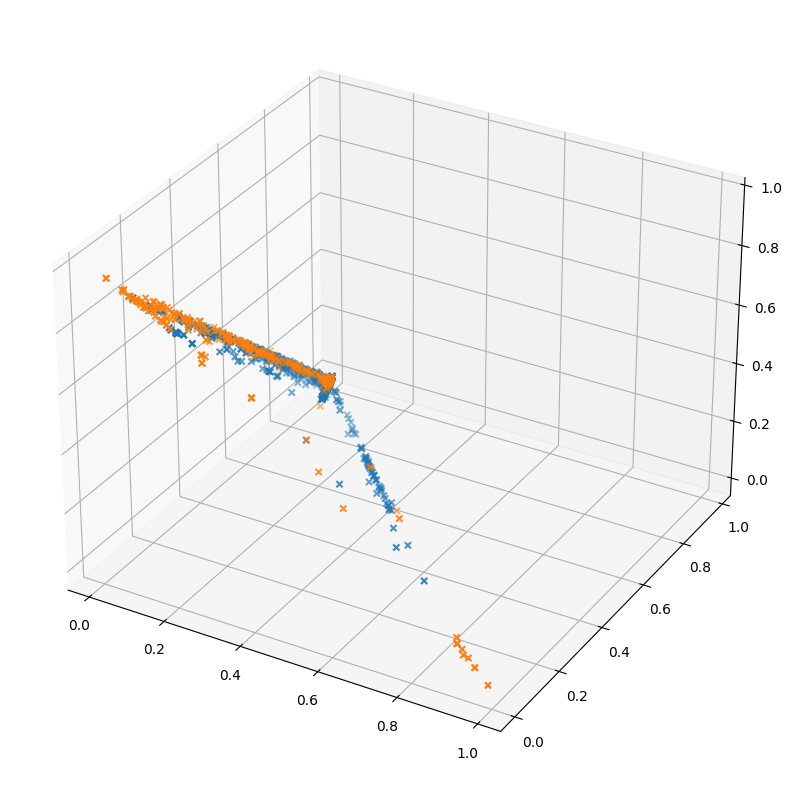

In [17]:
X_ham = X_LDA[y == 0]
X_spam = X_LDA[y == 1]

print(X_ham.shape, X_spam.shape)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

ax.scatter(X_ham[:, 0], X_ham[:, 1], X_ham[:, 2], marker="x")
ax.scatter(X_spam[:, 0], X_spam[:, 1], X_spam[:, 2], marker="x")

plt.show()

PCA Perform better here.

# Divide datasets to train and test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

print(f"Number of X train: {X_train.shape}, Number of y train: {y_train.shape}")
print(f"Number of X test: {X_test.shape}, Number of y test: {y_test.shape}")

Number of X train: (2288, 30986), Number of y train: (2288,)
Number of X test: (763, 30986), Number of y test: (763,)


# K - nearest

Accuracy:  0.9790301441677588
F-Measure:  0.9259259259259259
F-Measure (beta=0.5):  0.9009009009009008


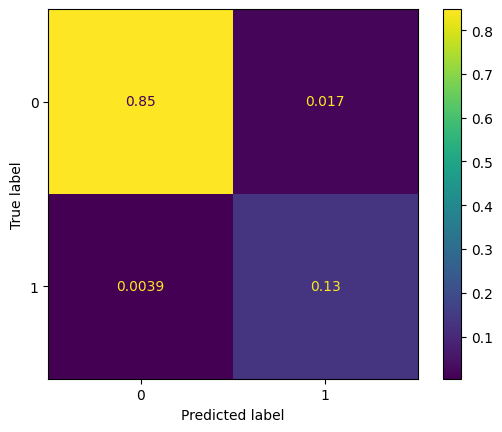

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Print accuracy
print("Accuracy: ", accuracy_score(y_test, y_pred))

# Print f-score
print("F-Measure: ", f1_score(y_test, y_pred))
print("F-Measure (beta=0.5): ", fbeta_score(y_test, y_pred, beta=0.5))

# Print confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="all"
)
plt.show()

# Naive Bayes

Accuracy:  0.9554390563564875
F-Measure:  0.8282828282828283
F-Measure (beta=0.5):  0.8488612836438924


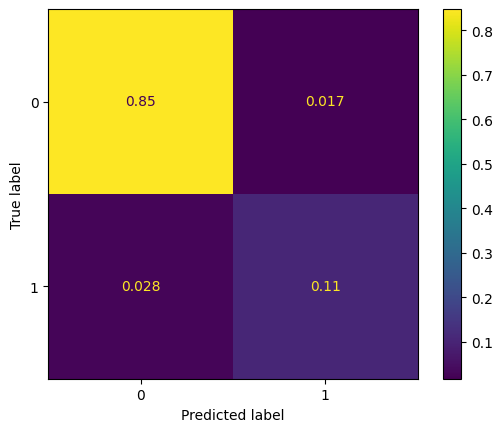

In [20]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

# Print accuracy
print("Accuracy: ", accuracy_score(y_test, y_pred))

# Print f-score
print("F-Measure: ", f1_score(y_test, y_pred))
print("F-Measure (beta=0.5): ", fbeta_score(y_test, y_pred, beta=0.5))

# Print confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="all"
)
plt.show()

# Decision Tree

Accuracy:  0.9593709043250328
F-Measure:  0.8457711442786069
F-Measure (beta=0.5):  0.8585858585858585


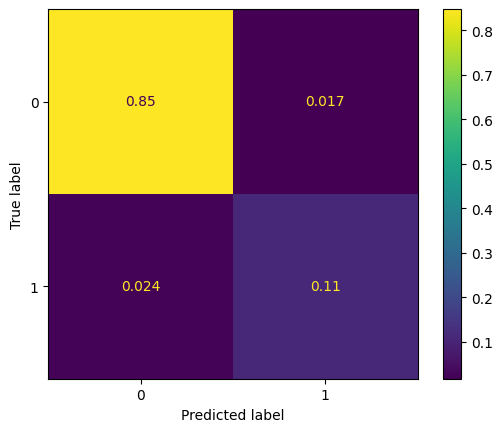

In [21]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

# Print accuracy
print("Accuracy: ", accuracy_score(y_test, y_pred))

# Print f-score
print("F-Measure: ", f1_score(y_test, y_pred))
print("F-Measure (beta=0.5): ", fbeta_score(y_test, y_pred, beta=0.5))

# Print confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="all"
)
plt.show()

# Random Forest

Accuracy:  0.9134993446920052
F-Measure:  0.5285714285714286
F-Measure (beta=0.5):  0.7370517928286853


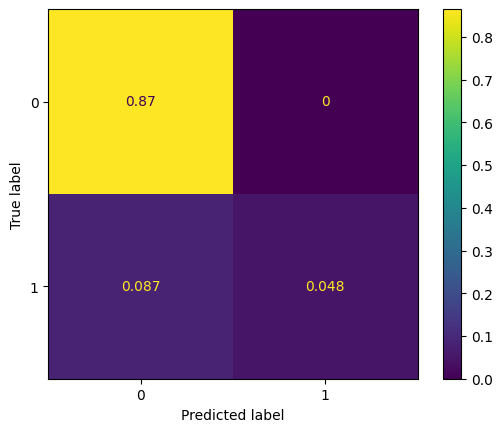

In [22]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=10, random_state=0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Print accuracy
print("Accuracy: ", accuracy_score(y_test, y_pred))
# Print f-score
print("F-Measure: ", f1_score(y_test, y_pred))
print("F-Measure (beta=0.5): ", fbeta_score(y_test, y_pred, beta=0.5))

# Print confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="all"
)
plt.show()


# SVM

Accuracy:  0.9790301441677588
F-Measure:  0.9157894736842105
F-Measure (beta=0.5):  0.9645232815964522


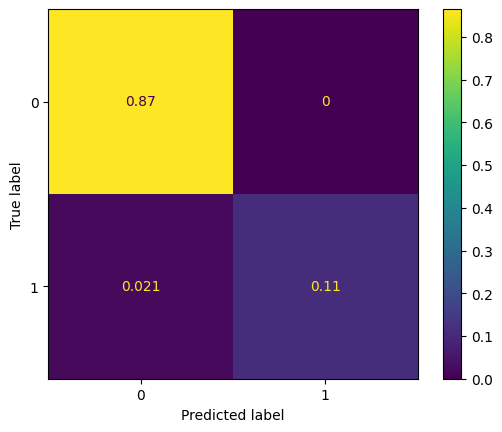

In [23]:
from sklearn import svm
clf = svm.SVC()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Print accuracy
print("Accuracy: ", accuracy_score(y_test, y_pred))
# Print f-score
print("F-Measure: ", f1_score(y_test, y_pred))
print("F-Measure (beta=0.5): ", fbeta_score(y_test, y_pred, beta=0.5))

# Print confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="all"
)
plt.show()

# Nueral Network


In [24]:
import torch
import torch.nn as nn
from tqdm.autonotebook import tqdm
from torch.utils.data import DataLoader, TensorDataset

device = "cuda"
losses = []

def train(model, loss_func, training_loader, epochs=100, device="cpu"):

    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    model = model.to(device)

    for epoch in tqdm(range(epochs), desc="Epoch"):
    
        model = model.train() 
        running_loss = 0.0

        for inputs, labels in training_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            y_hat = model(inputs)
            loss = loss_func(y_hat, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        losses.append(running_loss / len(training_loader))

dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
training_loader = DataLoader(dataset)

input_dim = X_train.shape[1]
model = nn.Sequential(
    nn.Linear(input_dim, 500),
    nn.ReLU(),
    nn.Linear(500, 100),
    nn.ReLU(),
    nn.Linear(100, 2), 
)

loss_func = nn.CrossEntropyLoss()
train(model, loss_func, training_loader, epochs=100, device=device)

/home/soohl/miniconda3/envs/venv/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epoch: 100%|██████████| 100/100 [08:34<00:00,  5.15s/it]


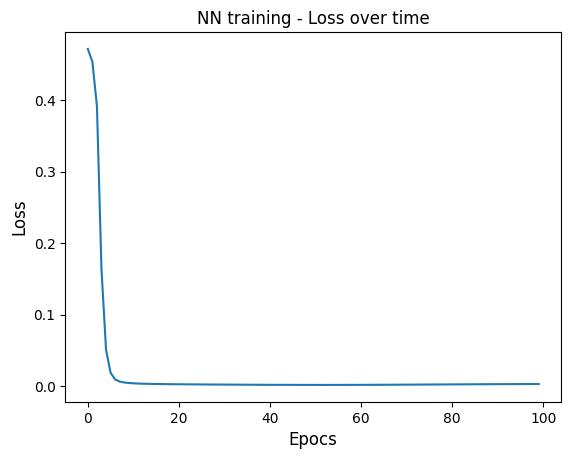

In [25]:
plt.plot(losses)
plt.title('NN training - Loss over time')
plt.xlabel('Epocs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.show()

In [26]:
dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
testing_loader = DataLoader(dataset)

correct = 0
with torch.no_grad():
    for inputs, labels in testing_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct // len(testing_loader)} %')

Accuracy: 93 %
